<a id="top"></a>
# Chapter 2 — Finite systems, spin and the Berry-phase machinery

**PythTB — Tight-Binding Physics from Theory to Code** · Part I — Fundamentals · chapter 2 of 8

[◀ 1 Foundations: chains, SSH, graphene and flat bands](PythTB_01_Foundations.ipynb) · [Contents of the book](README.md) · [3 Three dimensions, Wannier90 import and Wannierization ▶](PythTB_03_Three_Dimensions_and_Wannier.ipynb)

**In this chapter**

- [§6 Finite systems — `cut_piece`, edge states, and where electrons actually sit](#sec-6)
- [§7 Supercells and defects — `make_supercell`, `remove_orb`](#sec-7)
- [§8 Spin, natively — `spinful=True`](#sec-8)
- [§9 The Berry-phase machinery — `Mesh`, `WFArray`, and polarization](#sec-9)
- [§10 The Rice–Mele model and the Thouless pump](#sec-10)

All chapters: [0](PythTB_00_Introduction.ipynb) · [1](PythTB_01_Foundations.ipynb) · [2](PythTB_02_Finite_Systems_and_Berry_Phases.ipynb) · [3](PythTB_03_Three_Dimensions_and_Wannier.ipynb) · [4](PythTB_04_Chern_and_Z2.ipynb) · [5](PythTB_05_Higher_Order_and_Kitaev.ipynb) · [6](PythTB_06_Weyl_and_Axion.ipynb) · [7](PythTB_07_Stretching_PythTB.ipynb) · [8](PythTB_08_What_PythTB_Cannot_Do.ipynb) · exercises: [Parts I–II](PythTB_Exercises_I-II.ipynb) · [Parts III–IV](PythTB_Exercises_III-IV.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them, and a chapter that reuses a model from an earlier one rebuilds it in a short recap cell. Section numbers (§1–31), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import pythtb
from pythtb import Lattice, TBModel, Mesh, WFArray, Wannier, W90

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (7.0, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

# the Wannier90 silicon data (§12) lives in data/ at the repository root
DATA_DIR = next((d for d in ("data", os.path.join("..", "data")) if os.path.isdir(d)), "data")

rng = np.random.default_rng(2026)          # single seed for every stochastic cell

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 14}               # figure numbers run through the whole book

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def draw_bonds(ax, xy, pairs, color="0.55", lw=1.0, ls="-", zorder=1):
    '''Draw a set of bonds (index pairs) between the 2D points xy on axis ax —
    used throughout to depict the actual system before computing on it.'''
    for i, j in pairs:
        ax.plot(xy[[i, j], 0], xy[[i, j], 1], ls, color=color, lw=lw, zorder=zorder)

print("pythtb", pythtb.__version__, "| numpy", np.__version__, "| chapter 2")
t_chapter_start = time.time()

pythtb 2.0.0 | numpy 2.5.2 | chapter 2


In [2]:
# recap — rebuilt from §4 (chapter 1) so that this chapter runs on its own
def honeycomb(delta, t):
    '''Honeycomb-lattice model with staggered onsite ±delta and NN hopping t.'''
    lat = Lattice(lat_vecs=[[1.0, 0.0], [0.5, np.sqrt(3) / 2]],
                  orb_vecs=[[1/3, 1/3], [2/3, 2/3]], periodic_dirs=[0, 1])
    m = TBModel(lat)
    m.set_onsite([-delta, delta])
    m.set_hop(t, 0, 1, [0, 0])
    m.set_hop(t, 1, 0, [1, 0])
    m.set_hop(t, 1, 0, [0, 1])
    return m

<a id="sec-6"></a>

## 6. Finite systems — `cut_piece`, edge states, and where electrons actually sit

Two geometry operations turn a bulk model into something with boundaries:

- **`cut_piece(num_cells, periodic_dir, glue_edges=False)`** — replicate the cell `num_cells`
  times along one direction and open (or ring-close) the boundary. Applied once to a 2D model it
  makes a **ribbon**; twice, a **flake**.
- **`make_finite(periodic_dirs, num_cells)`** — cut several directions in one call.

The resulting object is the *same class* — a `TBModel` with fewer periodic directions — so every
solver and every Berry tool keeps working. For a fully finite model `solve_ham()` takes no
k-points and returns the cluster spectrum.

Physics on display: the SSH chain's **topological end modes** — two states exponentially pinned to
$E=0$ whenever the weak bond is cut — and the **flat edge band of zigzag graphene ribbons**.

> **PythTB cannot…** attach semi-infinite leads to these edges. A ribbon here is a closed box: we
> can see the edge *states*, but not the edge *conductance* they would carry. That is Kwant's half
> of the physics (Part IV, §25).

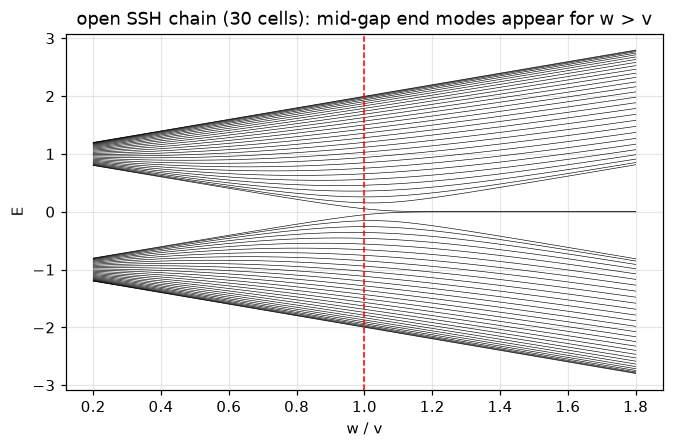

[PASS] topological SSH chain hosts exactly 2 end modes — states with |E| < 1e-3: 2


True

In [3]:
def ssh_model(v, w):
    lat = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.5]], periodic_dirs=[0])
    m = TBModel(lat)
    m.set_hop(v, 0, 1, [0])
    m.set_hop(w, 1, 0, [1])
    return m

# open-chain spectrum as the dimerization is swept through the transition
N_CELLS = 30
w_scan = np.linspace(0.2, 1.8, 60)
spectra = np.array([ssh_model(1.0, w).cut_piece(N_CELLS, 0).solve_ham() for w in w_scan])

fig, ax = plt.subplots()
ax.plot(w_scan, spectra, "k-", lw=0.4)
ax.axvline(1.0, color="r", ls="--", lw=1)
ax.set_xlabel("w / v")
ax.set_ylabel("E")
ax.set_title(f"open SSH chain ({N_CELLS} cells): mid-gap end modes appear for w > v")
plt.show()
caption("Spectrum of an open SSH chain versus dimerization. For w < v the finite "
        "chain simply shows the bulk bands with a clean gap; the moment w exceeds v "
        "the chain terminates on weak bonds, and two states peel off into the gap "
        "and pin exponentially to E = 0: the bulk-boundary correspondence in its "
        "simplest incarnation — the bulk invariant (Berry phase π, computed in §9) "
        "forces boundary states to exist, whatever the microscopic details of the cut.")

evals_topo = ssh_model(1.0, 1.6).cut_piece(N_CELLS, 0).solve_ham()
n_zero = int(np.sum(np.abs(evals_topo) < 1e-3))
check("topological SSH chain hosts exactly 2 end modes", n_zero == 2,
      f"states with |E| < 1e-3: {n_zero}")

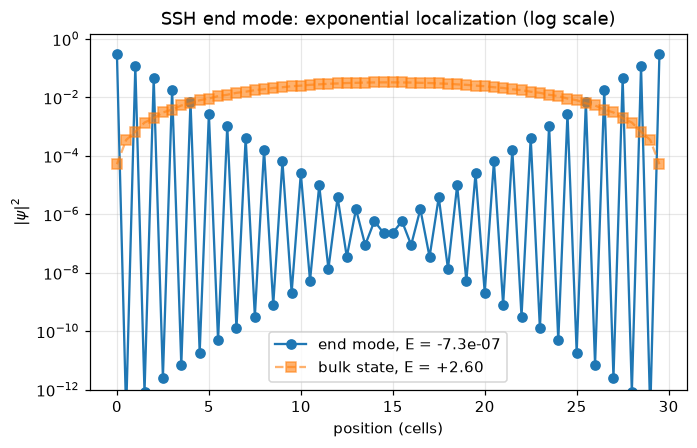

[PASS] end-mode decay follows (v/w)^2 per cell — measured 0.3906 vs (v/w)^2 = 0.3906


True

In [4]:
# where do the end modes live?  |psi|^2 across the chain, compared with a bulk state
fin = ssh_model(1.0, 1.6).cut_piece(N_CELLS, 0)
evals, evecs = fin.solve_ham(return_eigvecs=True)
x = fin.orb_vecs[:, 0]                            # orbital positions in units of the cell

idx_edge = np.argsort(np.abs(evals))[0]           # one of the two E≈0 states
idx_bulk = np.argmax(evals)                       # top of the spectrum: a bulk state

fig, ax = plt.subplots()
ax.semilogy(x, np.abs(evecs[idx_edge]) ** 2, "o-", label=f"end mode, E = {evals[idx_edge]:+.1e}")
ax.semilogy(x, np.abs(evecs[idx_bulk]) ** 2, "s--", alpha=0.6,
            label=f"bulk state, E = {evals[idx_bulk]:+.2f}")
ax.set_xlabel("position (cells)")
ax.set_ylabel(r"$|\psi|^2$")
ax.set_ylim(1e-12, 1.5)
ax.legend()
ax.set_title("SSH end mode: exponential localization (log scale)")
plt.show()
caption("Where the end mode lives: |ψ|² of one E ≈ 0 state (circles) against a "
        "generic bulk state (squares), on a log scale. The end mode decays "
        "exponentially with decay factor (v/w)² per cell and — a chiral-symmetry "
        "fingerprint — has weight on only ONE sublattice: the even-numbered points "
        "interlace the odd ones because alternate sites carry strictly zero amplitude.")

# exponential envelope check: |psi|^2 drops by (v/w)^2 per cell on the A sublattice
dens = np.abs(evecs[idx_edge]) ** 2
ratio = dens[4] / dens[2]                         # A-sites of neighbouring cells 1 and 2
check("end-mode decay follows (v/w)^2 per cell",
      np.isclose(ratio, (1.0 / 1.6) ** 2, rtol=0.15),
      f"measured {ratio:.4f} vs (v/w)^2 = {(1.0/1.6)**2:.4f}")

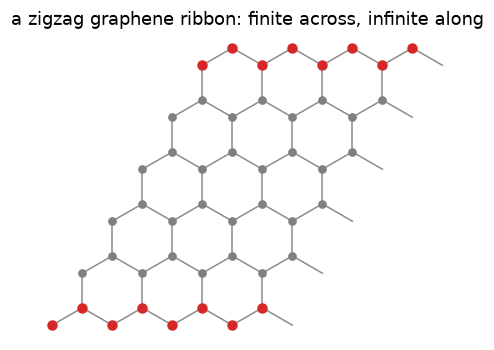

In [5]:
# what a ribbon IS: the honeycomb cut to a finite number of cells along a2,
# still infinite (periodic) along a1 — drawn here with the edge atoms highlighted
graphene = honeycomb(delta=0.0, t=-1.0)
rib_demo = graphene.cut_piece(6, 1, glue_edges=False)
pos_r = rib_demo.orb_vecs @ rib_demo.lat_vecs

fig, ax = plt.subplots(figsize=(8.5, 3.6))
for shift in (-1, 0, 1, 2):                        # repeat cells along the periodic dir
    p = pos_r + shift * rib_demo.lat_vecs[0]
    d2r = np.sum((p[:, None, :] - p[None, :, :]) ** 2, axis=-1)
    # NN bonds inside this repeated block
    draw_bonds(ax, p, [(i, j) for i, j in zip(*np.where(np.abs(d2r - 1/3) < 1e-6)) if i < j])
    # bonds between neighbouring blocks
    q = pos_r + (shift + 1) * rib_demo.lat_vecs[0]
    for i in range(len(p)):
        for j in range(len(q)):
            if abs(np.sum((p[i] - q[j]) ** 2) - 1/3) < 1e-6:
                ax.plot([p[i, 0], q[j, 0]], [p[i, 1], q[j, 1]], "-", color="0.55", lw=1)
    edge_mask = (pos_r[:, 1] < pos_r[:, 1].min() + 0.3) | (pos_r[:, 1] > pos_r[:, 1].max() - 0.3)
    ax.scatter(p[~edge_mask, 0], p[~edge_mask, 1], s=22, c="0.5", zorder=3)
    ax.scatter(p[edge_mask, 0], p[edge_mask, 1], s=34, c="C3", zorder=4)
ax.annotate("periodic →", (pos_r[:, 0].mean() + 1.0, pos_r[:, 1].max() + 0.45),
            fontsize=11, color="0.3")
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("a zigzag graphene ribbon: finite across, infinite along")
plt.show()
caption("The ribbon geometry produced by cut_piece: six cells wide, periodic along "
        "the horizontal direction (a few periods are drawn). The outermost atoms "
        "(red) form zigzag edges, and — crucially — the top and bottom edge atoms "
        "belong to OPPOSITE sublattices. The flat edge band in the next figure lives "
        "on exactly these red sites.")

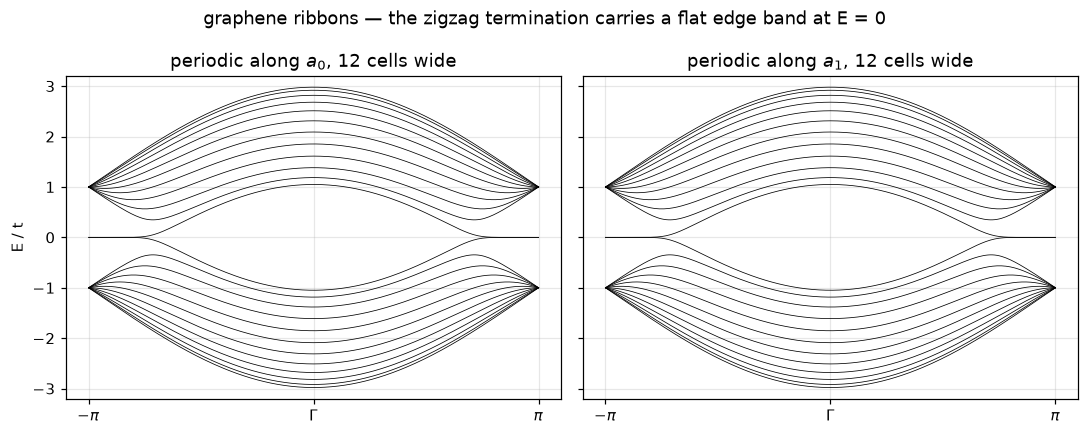

[PASS] zigzag ribbon has zero modes at k = π — |E| < 0.05: 2 states


True

In [6]:
# graphene ribbons: band structures for cuts along each lattice direction
NW = 12                                            # ribbon width in cells

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, cut_dir in zip(axs, (1, 0)):
    rib = graphene.cut_piece(NW, cut_dir, glue_edges=False)
    k_vec, k_dist, k_node = rib.k_path([[-0.5], [0.0], [0.5]], nk=201, report=False)
    ev = rib.solve_ham(k_vec)
    ax.plot(k_dist, ev, "k-", lw=0.5)
    ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
    ax.set_title(f"periodic along $a_{1-cut_dir}$, {NW} cells wide")
    ax.set_ylim(-3.2, 3.2)
axs[0].set_ylabel("E / t")
fig.suptitle("graphene ribbons — the zigzag termination carries a flat edge band at E = 0")
fig.tight_layout()
plt.show()
caption("Ribbon band structures for the two cut directions. Between the projections "
        "of K and K' (around k = π) a nearly flat band sits at E = 0: these are the "
        "zigzag edge states, one per edge, living on a single sublattice. Their "
        "flatness (zero velocity) concentrates density of states at the Fermi level "
        "of neutral graphene — the seed of the edge magnetism computed in §29.")

# the flat band at the zone boundary is edge physics: count E≈0 states at k = 1/2
rib = graphene.cut_piece(NW, 1, glue_edges=False)
ev_pi = np.atleast_2d(rib.solve_ham(np.array([[0.5]])))[0]
check("zigzag ribbon has zero modes at k = π",
      np.sum(np.abs(ev_pi) < 5e-2) >= 2,
      f"|E| < 0.05: {int(np.sum(np.abs(ev_pi) < 5e-2))} states")

<a id="sec-7"></a>

## 7. Supercells and defects — `make_supercell`, `remove_orb`

**`make_supercell(M)`** builds the model on a larger cell defined by integer combinations of the
original lattice vectors (rows of `M`), remapping every hopping. Bands *fold*: a $3\times3$
graphene supercell maps both $K$ and $K'$ onto $\Gamma$ — the Dirac cones reappear stacked at zone
center. Folding is not just bookkeeping: it is the standard trick for commensurate perturbations
(§21 uses it for magnetic flux), and supercell + defect is the poor man's disorder (§25).

**`remove_orb(i)`** deletes orbitals — a vacancy. On a bipartite lattice, removing one A-site
leaves $N_B = N_A + 1$, and the bipartite theorem guarantees at least one exact zero mode living
entirely on the B sublattice, localized around the vacancy. We build a graphene flake, punch out
the central atom, and look at the state that appears.

primitive cell: 2 orbitals  ->  3x3 supercell: 18 orbitals


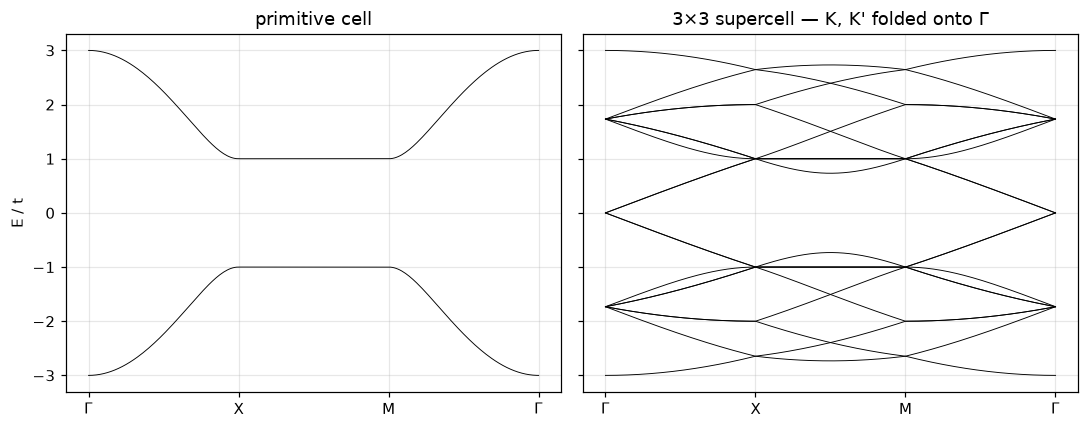

[PASS] supercell folds Dirac points onto Γ (E = 0 states at zone center) — zero-energy states at Γ: 4


True

In [7]:
# band folding: 3x3 graphene supercell
sc = graphene.make_supercell([[3, 0], [0, 3]])
print(f"primitive cell: {graphene.norb} orbitals  ->  3x3 supercell: {sc.norb} orbitals")

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, m, title in ((axs[0], graphene, "primitive cell"),
                     (axs[1], sc, "3×3 supercell — K, K' folded onto Γ")):
    k_vec, k_dist, k_node = m.k_path([[0, 0], [0.5, 0.0], [0.5, 0.5], [0, 0]],
                                     nk=241, report=False)
    ev = m.solve_ham(k_vec)
    ax.plot(k_dist, ev, "k-", lw=0.6)
    ax.set_xticks(k_node, [r"$\Gamma$", "X", "M", r"$\Gamma$"])
    ax.set_title(title)
axs[0].set_ylabel("E / t")
fig.tight_layout()
plt.show()
caption("Band folding: the same graphene crystal described in its primitive cell "
        "(left) and in a 3×3 supercell (right). Nothing physical changed — the "
        "supercell BZ is 9× smaller, so the bands fold back 9× denser, and both "
        "Dirac points land on Γ. Folding is the price of any supercell treatment "
        "(defects, disorder, magnetic flux) and must not be mistaken for new physics.")

ev_gamma = np.atleast_2d(sc.solve_ham(np.array([[0.0, 0.0]])))[0]
check("supercell folds Dirac points onto Γ (E = 0 states at zone center)",
      np.sum(np.abs(ev_gamma) < 1e-9) >= 4,
      f"zero-energy states at Γ: {int(np.sum(np.abs(ev_gamma) < 1e-9))}")

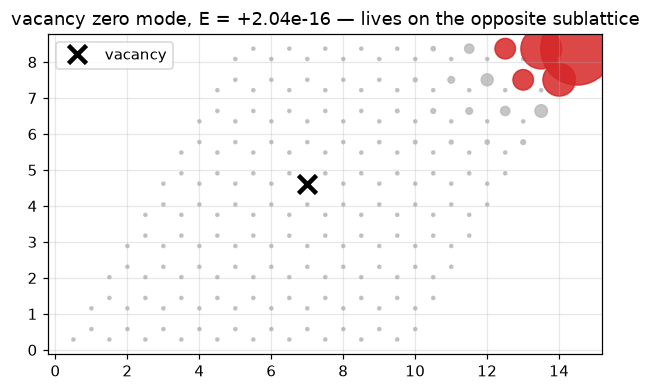

[PASS] vacancy creates a zero mode — E = 2.04e-16
[PASS] zero mode lives on the B sublattice — B-sublattice weight = 1.000000


True

In [8]:
# vacancy in a graphene flake: bipartite zero mode
L = 10
flake = graphene.make_finite(periodic_dirs=[0, 1], num_cells=[L, L])

# remove the A-site closest to the flake center
pos = flake.orb_vecs @ flake.lat_vecs                 # Cartesian positions
center = pos.mean(axis=0)
a_sites = np.arange(0, flake.norb, 2)                  # even indices = A sublattice
i_kill = a_sites[np.argmin(np.linalg.norm(pos[a_sites] - center, axis=1))]
vac = flake.copy()
vac.remove_orb(int(i_kill))       # NB: mutates in place (returns None) — despite the docstring

evals, evecs = vac.solve_ham(return_eigvecs=True)
i0 = np.argmin(np.abs(evals))
dens = np.abs(evecs[i0]) ** 2
pos_v = vac.orb_vecs @ vac.lat_vecs

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(pos_v[:, 0], pos_v[:, 1], s=4 + 4000 * dens, c=["#d62728" if d > dens.max() / 20
           else "#bbbbbb" for d in dens], alpha=0.85)
ax.plot(*pos[i_kill], "kx", ms=12, mew=3, label="vacancy")
ax.set_aspect("equal")
ax.legend()
ax.set_title(f"vacancy zero mode, E = {evals[i0]:+.2e} — lives on the opposite sublattice")
plt.show()
caption("A single vacancy in a graphene flake (black cross) and the zero mode it "
        "creates (red, symbol size ∝ |ψ|²). Removing one A-site leaves the B "
        "sublattice with one extra site, and on any bipartite lattice that imbalance "
        "guarantees an exact E = 0 state confined to the majority sublattice — "
        "decaying as a power law around the missing atom. The proof is counting, "
        "not perturbation theory, so the mode survives at any hopping strength.")

check("vacancy creates a zero mode", np.abs(evals[i0]) < 1e-10,
      f"E = {evals[i0]:.2e}")
# sublattice purity: the removed site was A, so the mode should be ~100% on B
b_mask = (np.arange(vac.norb + 1) % 2 == 1)            # odd indices were B before removal
b_mask = np.delete(b_mask, i_kill)
check("zero mode lives on the B sublattice", dens[b_mask].sum() > 0.999,
      f"B-sublattice weight = {dens[b_mask].sum():.6f}")

<a id="sec-8"></a>

## 8. Spin, natively — `spinful=True`

Classic PythTB 1.x treated spin through the `nspin=2` option with a clunky 4-vector notation;
PythTB 2.0 makes it a first-class flag: `TBModel(lattice, spinful=True)` doubles every orbital
into a Kramers pair, and onsite/hopping amplitudes become either

- a scalar $t$ → spin-diagonal $t\,\sigma_0$,
- a 4-vector $[a_0, a_x, a_y, a_z]$ → $a_0\sigma_0 + a_x\sigma_x + a_y\sigma_y + a_z\sigma_z$, or
- an explicit $2\times2$ (complex) matrix.

Demo: the textbook **Rashba wire in a Zeeman field**,
$$
H(k) = -2t\cos K \,\sigma_0 \;-\; 2\alpha \sin K\,\sigma_y \;+\; B\,\sigma_z, \qquad K = 2\pi k,
$$
whose spectrum $E_\pm = -2t\cos K \pm \sqrt{4\alpha^2\sin^2 K + B^2}$ develops the *helical gap* at
$k=0$ that underlies the Majorana nanowire recipe (we return to it in Part II, where the missing
ingredient — superconductivity — has to be faked by hand).

norb = 1, nspin = 2, nstate = 2


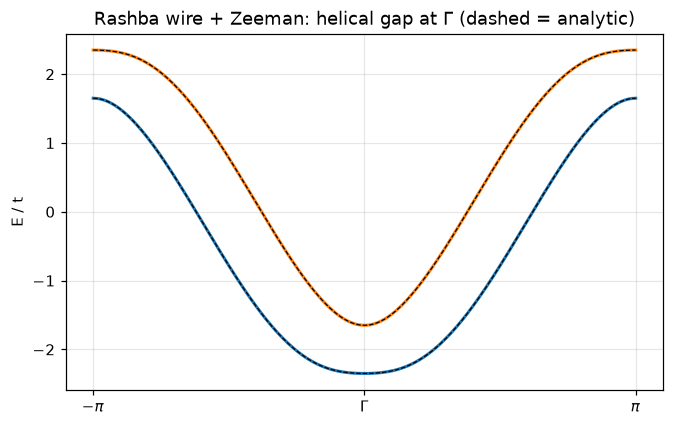

[PASS] spinful wire matches analytic Rashba+Zeeman dispersion


True

In [9]:
t, alpha, B = 1.0, 0.35, 0.35
sy = np.array([[0, -1j], [1j, 0]])

lat_wire = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0]], periodic_dirs=[0])
wire = TBModel(lat_wire, spinful=True)
wire.set_onsite([[0.0, 0.0, 0.0, B]])                 # 4-vector: B sigma_z
wire.set_hop(-t * np.eye(2) + 1j * alpha * sy, 0, 0, [1])   # explicit 2x2 hop matrix
print(f"norb = {wire.norb}, nspin = {wire.nspin}, nstate = {wire.nstate}")

k_vec, k_dist, k_node = wire.k_path([[-0.5], [0.0], [0.5]], nk=301, report=False)
ev = wire.solve_ham(k_vec)

K = 2 * np.pi * k_vec[:, 0]
E_exact = np.array([-2 * t * np.cos(K) - np.sqrt(4 * alpha**2 * np.sin(K)**2 + B**2),
                    -2 * t * np.cos(K) + np.sqrt(4 * alpha**2 * np.sin(K)**2 + B**2)]).T

fig, ax = plt.subplots()
ax.plot(k_dist, ev, lw=2)
ax.plot(k_dist, E_exact, "k--", lw=0.8)
ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
ax.set_ylabel("E / t")
ax.set_title("Rashba wire + Zeeman: helical gap at Γ (dashed = analytic)")
plt.show()
caption("Bands of the spinful wire. Rashba coupling alone would give two shifted "
        "bands crossing at k = 0; the Zeeman field opens the 'helical gap' at that "
        "crossing. Tuning the chemical potential into this gap leaves a single pair "
        "of counter-propagating, spin-momentum-locked modes — the starting point of "
        "every Majorana nanowire proposal.")

check("spinful wire matches analytic Rashba+Zeeman dispersion",
      np.allclose(np.sort(ev, axis=1), np.sort(E_exact, axis=1), atol=1e-10))

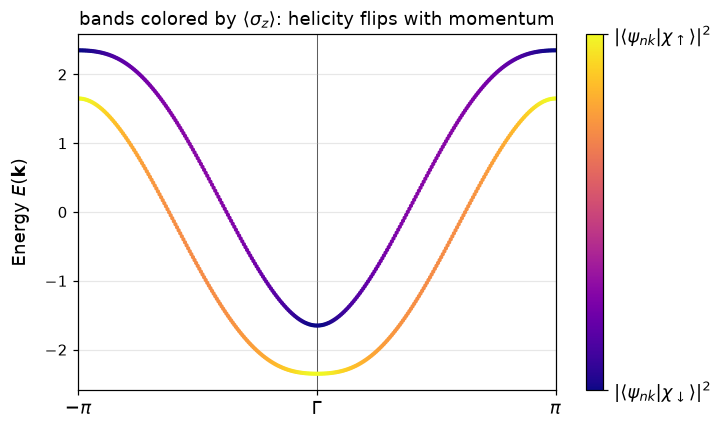

In [10]:
# spin-resolved bands: plot_bands can color by <sigma_z>
fig, ax = wire.plot_bands([[-0.5], [0.0], [0.5]], k_node_labels=[r"$-\pi$", r"$\Gamma$", r"$\pi$"],
                          nk=301, proj_spin=True)
ax.set_title(r"bands colored by $\langle\sigma_z\rangle$: helicity flips with momentum")
plt.show()
caption("The same bands colored by the spin projection ⟨σz⟩ (plot_bands with "
        "proj_spin): near k = 0 the Zeeman term dominates and polarizes the spins "
        "along z; at larger |k| the Rashba field wins and rotates them into the y "
        "direction, the color fading toward the middle of the scale.")

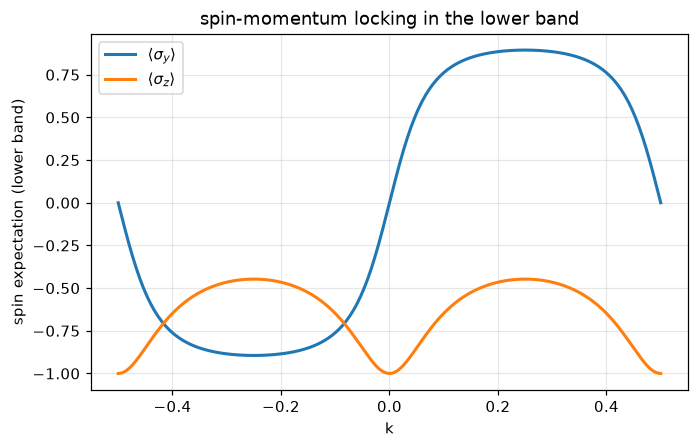

In [11]:
# the full spin texture: expectation values of sigma_y and sigma_z along the
# lower band, computed directly from the eigenvectors
_, vec_w = wire.solve_ham(k_vec, return_eigvecs=True)
sy_tex = np.array([[0, -1j], [1j, 0]])
sz_tex = np.diag([1.0, -1.0])
psi_low = vec_w[:, 0, :]                       # lower band, (nk, 2 spin components)
exp_sy = np.real(np.einsum("ks,st,kt->k", psi_low.conj(), sy_tex, psi_low))
exp_sz = np.real(np.einsum("ks,st,kt->k", psi_low.conj(), sz_tex, psi_low))

fig, ax = plt.subplots()
ax.plot(k_vec[:, 0], exp_sy, lw=2, label=r"$\langle\sigma_y\rangle$")
ax.plot(k_vec[:, 0], exp_sz, lw=2, label=r"$\langle\sigma_z\rangle$")
ax.set_xlabel("k"); ax.set_ylabel("spin expectation (lower band)")
ax.legend(); ax.set_title("spin-momentum locking in the lower band")
plt.show()
caption("Spin texture of the lower band: ⟨σy⟩ is odd in k (the Rashba field is "
        "∝ sin k · σy) while ⟨σz⟩ is even and peaks at k = 0 where the Zeeman term "
        "rules. A right-mover and a left-mover at the same energy inside the helical "
        "gap therefore carry nearly opposite spins — backscattering requires a spin "
        "flip, which is what protects helical transport.")

<a id="sec-9"></a>

## 9. The Berry-phase machinery — `Mesh`, `WFArray`, and polarization

This is PythTB's reason to exist. For a band $|u_{n\mathbf{k}}\rangle$ transported around a closed
loop $\mathcal{C}$ in parameter space, the **Berry phase**
$$
\phi = \oint_{\mathcal C} \langle u | i\nabla_{\mathbf k} u\rangle\cdot d\mathbf k
$$
is gauge-invariant modulo $2\pi$. Numerically it is computed from the gauge-independent discrete
formula (King-Smith–Vanderbilt):
$$
\phi = -\,\mathrm{Im}\ln \prod_{j} \det M^{(j,j+1)}, \qquad
M^{(j,j+1)}_{mn} = \langle u_{m,\mathbf k_j} | u_{n,\mathbf k_{j+1}}\rangle,
$$
which is exactly what `WFArray.berry_phase` evaluates (and `wilson_loop` returns the full
eigenvalue spectrum of the product, needed for $\mathbb{Z}_2$ invariants in Part II).

The physical payoff in 1D is the **modern theory of polarization**: the electronic contribution is
$P = e\,\phi/2\pi$ per cell — a bulk quantity defined only modulo $e$, whose *changes* are
measurable currents. In PythTB convention I, $\bar x = \phi/2\pi$ is literally the Wannier-center
position in reduced coordinates.

Workflow: build a `Mesh` (k-grids, λ-axes, paths, loops) → fill a `WFArray` with eigenstates via
`solve_model` → ask for `berry_phase`, `berry_flux`, `berry_curvature`, `chern_number`,
`wilson_loop`, `position_hwf`. The array knows which axes wind the Brillouin zone and applies the
convention-I boundary phases automatically.

In [12]:
# SSH polarization: Wannier center of the occupied band in both dimerizations
def ssh_wannier_center(v, w, nk=101):
    m = ssh_model(v, w)
    mesh = Mesh(["k"])
    mesh.build_grid([nk], k_endpoints=True)
    wfa = WFArray(m.lattice, mesh)
    wfa.solve_model(m)
    phi = float(np.squeeze(wfa.berry_phase(axis_idx=0, state_idx=[0])))
    return (phi / (2 * np.pi)) % 1.0

x_triv = ssh_wannier_center(1.0, 0.5)
x_topo = ssh_wannier_center(0.5, 1.0)
print(f"Wannier center, trivial   (v>w): x̄ = {x_triv:.6f}  (on the intracell bond, 0.25)")
print(f"Wannier center, topological(v<w): x̄ = {x_topo:.6f}  (on the intercell bond, 0.75)")

check("SSH Wannier centers sit on bond centers",
      np.isclose(x_triv, 0.25, atol=1e-6) and np.isclose(x_topo, 0.75, atol=1e-6))
check("the two phases differ by half a lattice vector (Berry phase π)",
      np.isclose(abs(x_topo - x_triv), 0.5, atol=1e-6),
      f"Δx̄ = {abs(x_topo - x_triv):.6f}")

Wannier center, trivial   (v>w): x̄ = 0.250000  (on the intracell bond, 0.25)
Wannier center, topological(v<w): x̄ = 0.750000  (on the intercell bond, 0.75)
[PASS] SSH Wannier centers sit on bond centers
[PASS] the two phases differ by half a lattice vector (Berry phase π) — Δx̄ = 0.500000


True

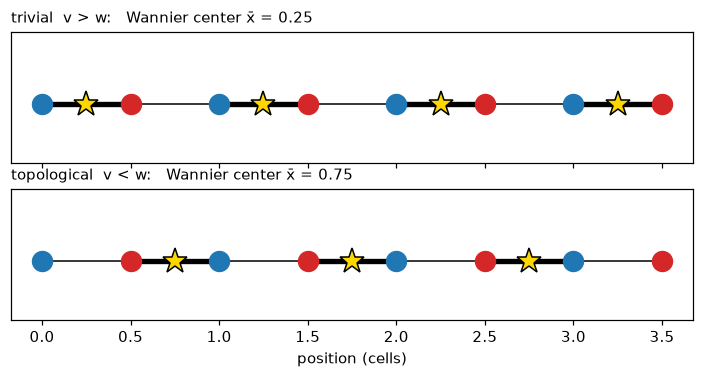

In [13]:
# the Berry phase made tangible: draw where the electron's charge center actually
# sits on the chain in each phase
fig, axs = plt.subplots(2, 1, figsize=(8, 3.4), sharex=True)
for ax, (v, w, xbar, tag) in zip(axs, [(1.0, 0.5, x_triv, "trivial  v > w"),
                                       (0.5, 1.0, x_topo, "topological  v < w")]):
    for c in range(4):
        ax.plot([c], [0], "o", ms=13, color="C0", zorder=3)
        ax.plot([c + 0.5], [0], "o", ms=13, color="C3", zorder=3)
        ax.plot([c, c + 0.5], [0, 0], "-", color="k", lw=3.5 if v > w else 1.0)
        if c < 3:
            ax.plot([c + 0.5, c + 1], [0, 0], "-", color="k", lw=1.0 if v > w else 3.5)
    for c in range(4 if xbar < 0.5 else 3):
        ax.plot([c + xbar], [0], "*", ms=17, color="gold", mec="k", zorder=4)
    ax.set_ylim(-0.4, 0.5); ax.set_yticks([])
    ax.set_title(f"{tag}:   Wannier center x̄ = {xbar:.2f}", fontsize=10, loc="left")
    ax.grid(False)
axs[1].set_xlabel("position (cells)")
plt.show()
caption("The polarization difference, drawn: the occupied band's Wannier center "
        "(star) sits at the middle of whichever bond is STRONG — x̄ = ¼ inside the "
        "cell in the trivial phase, x̄ = ¾ (on the intercell bond) in the topological "
        "one. Cutting the chain through a strong bond costs an end state: comparing "
        "the two rows shows immediately why the topological chain, terminated at a "
        "cell boundary, must leave half an electron's worth of charge behind at "
        "each end.")

In [14]:
# the same number three ways: berry_phase, wilson_loop eigenvalues, and the
# hybrid-Wannier-center routine position_hwf — they must agree
m = ssh_model(1.0, 0.5)
mesh = Mesh(["k"]); mesh.build_grid([101], k_endpoints=True)
wfa = WFArray(m.lattice, mesh); wfa.solve_model(m)

phi_bp = float(np.squeeze(wfa.berry_phase(axis_idx=0, state_idx=[0])))
# NB upstream bug (pythtb 2.0.2): the wilson_evals=True return path stores the
# complex eigenvalues e^{i phi} into a float array, silently returning cos(phi).
# The Wilson unitary itself is correct — diagonalize it yourself. The bug's only
# visible symptom is a numpy ComplexWarning raised inside pythtb; silence it so the
# output stays clean (the workaround below does not depend on it).
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", np.exceptions.ComplexWarning)
    U_wilson, _ = wfa.wilson_loop(axis_idx=0, state_idx=[0], wilson_evals=True)
lam = np.linalg.eigvals(np.atleast_2d(np.squeeze(U_wilson)))
phi_wl = float(-np.angle(lam[0]))                  # same sign convention as berry_phase

print(f"berry_phase : φ = {phi_bp:+.8f}")
print(f"wilson_loop : φ = {phi_wl:+.8f}")
check("Wilson-loop eigenvalue reproduces the Berry phase",
      np.isclose(np.exp(1j * phi_bp), np.exp(1j * phi_wl), atol=1e-8))

# gauge invariance: shifting where the k-loop starts must not change φ (mod 2π)
mesh2 = Mesh(["k"]); mesh2.build_grid([101], k_endpoints=True, gamma_centered=True)
wfa2 = WFArray(m.lattice, mesh2); wfa2.solve_model(m)
phi_shift = float(np.squeeze(wfa2.berry_phase(axis_idx=0, state_idx=[0])))
check("Berry phase is independent of loop origin (gauge invariance)",
      np.isclose(np.exp(1j * phi_bp), np.exp(1j * phi_shift), atol=1e-8),
      f"Δφ = {abs(phi_bp - phi_shift):.2e} mod 2π")

berry_phase : φ = +1.57079633
wilson_loop : φ = +1.57079633
[PASS] Wilson-loop eigenvalue reproduces the Berry phase
[PASS] Berry phase is independent of loop origin (gauge invariance) — Δφ = 4.44e-16 mod 2π


True

<a id="sec-10"></a>

## 10. The Rice–Mele model and the Thouless pump

Add to SSH a staggered onsite $\pm\Delta$ and you get the **Rice–Mele model** — the minimal
insulator with *no* quantizing symmetry, whose polarization can take any value. Now drive the
parameters around a cycle enclosing the SSH critical point:
$$
v(\lambda) = t + \delta\cos 2\pi\lambda, \qquad
\Delta(\lambda) = \Delta_0 \sin 2\pi\lambda .
$$
Thouless (1983): after one adiabatic cycle the polarization returns to itself, but the Wannier
center has *wound around the cell an integer number of times* — exactly one electron pumped per
cycle per band. That integer is a **Chern number in the $(k,\lambda)$ torus**, and it is the same
mathematics as the quantum Hall effect one dimension up.

This is where PythTB's abstraction shines: a `Mesh` can mix k-axes and λ-axes, and the model's
parameters can be *functions* of λ. The `WFArray` then treats the pump cycle exactly like a
Brillouin zone.

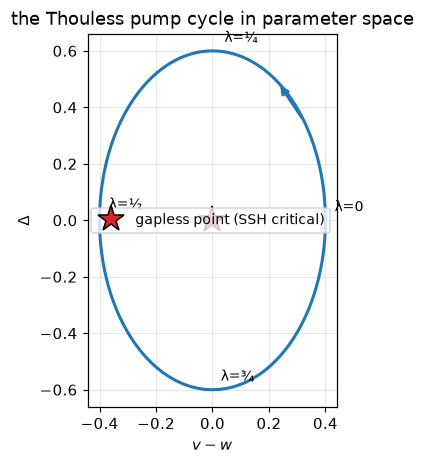

In [15]:
# the pump protocol seen in parameter space: the cycle must ENCIRCLE the
# gapless point (v - w, Delta) = (0, 0)
lam_c = np.linspace(0, 1, 200)
v_minus_w = 0.4 * np.cos(2 * np.pi * lam_c)          # v(λ) - w  (δ-modulation)
Delta_c = 0.6 * np.sin(2 * np.pi * lam_c)

fig, ax = plt.subplots(figsize=(4.8, 4.4))
ax.plot(v_minus_w, Delta_c, lw=2, color="C0")
ax.annotate("", xy=(v_minus_w[30], Delta_c[30]), xytext=(v_minus_w[20], Delta_c[20]),
            arrowprops=dict(arrowstyle="-|>", color="C0", lw=2))
ax.plot(0, 0, "*", ms=18, color="C3", mec="k", label="gapless point (SSH critical)")
for lv, name in [(0.0, "λ=0"), (0.25, "λ=¼"), (0.5, "λ=½"), (0.75, "λ=¾")]:
    i = int(lv * 199)
    ax.annotate(name, (v_minus_w[i], Delta_c[i]), textcoords="offset points",
                xytext=(6, 6), fontsize=9)
ax.set_xlabel(r"$v - w$"); ax.set_ylabel(r"$\Delta$")
ax.legend(fontsize=9); ax.set_aspect("equal")
ax.set_title("the Thouless pump cycle in parameter space")
plt.show()
caption("The pump protocol: over one period the dimerization (v − w) and the "
        "staggered onsite Δ trace a loop that encircles the SSH critical point "
        "(star), where the bulk gap would close. The pumped charge equals the "
        "winding number of this loop around the star — which is why the off-center "
        "cycle of exercise I.5 pumps nothing. Enclosing a gapless point is to a "
        "pump what enclosing a solenoid is to an Aharonov–Bohm phase.")

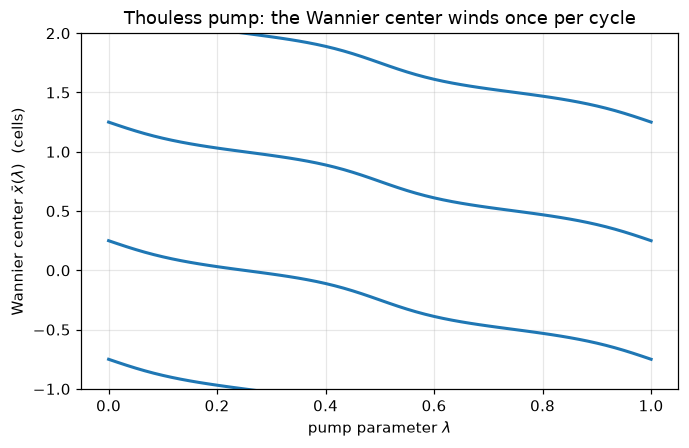

Wannier winding over one cycle: -1.000000
Chern number on the (k,λ) torus: +1.000000
[PASS] pumped charge is exactly one electron per cycle


True

In [16]:
# Rice-Mele pump: parameters as callables of lmbda
t0, d0, D0 = 1.0, 0.4, 0.6
lat_rm = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.5]], periodic_dirs=[0])
rm = TBModel(lat_rm)
rm.set_onsite([lambda lmbda: -D0 * np.sin(2 * np.pi * lmbda),
               lambda lmbda: +D0 * np.sin(2 * np.pi * lmbda)])
rm.set_hop(lambda lmbda: t0 + d0 * np.cos(2 * np.pi * lmbda), 0, 1, [0])
rm.set_hop(t0, 1, 0, [1])

mesh = Mesh(["k", "l"], axis_names=["k", "lmbda"])
mesh.build_grid(shape=(41, 61), k_endpoints=True,
                lambda_start=0.0, lambda_stop=1.0, lambda_endpoints=True)
mesh.loop(axis_idx=1, component_idx=1, closed=True)     # λ-axis is a closed cycle
wfa = WFArray(lat_rm, mesh)
wfa.solve_model(rm)

lam = mesh.get_axis_range(1, 1)
xbar = np.array(wfa.berry_phase(axis_idx=0, state_idx=[0], contin=True)) / (2 * np.pi)

fig, ax = plt.subplots()
for shift in (-1, 0, 1, 2):
    ax.plot(lam, xbar + shift, "C0-", lw=2)
ax.set_xlabel(r"pump parameter $\lambda$")
ax.set_ylabel(r"Wannier center $\bar x(\lambda)$  (cells)")
ax.set_ylim(-1, 2)
ax.set_title("Thouless pump: the Wannier center winds once per cycle")
plt.show()
caption("Wannier-center flow over one pump cycle (several unit cells shown). The "
        "charge center advances smoothly and ends one full lattice constant from "
        "where it started: exactly one electron per cell has been transported, "
        "with no bias voltage — quantized by the Chern number of the (k, λ) torus, "
        "not by any fine-tuning of the drive.")

winding = xbar[-1] - xbar[0]
C_pump = float(wfa.chern_number(plane=(0, 1), state_idx=[0]))
print(f"Wannier winding over one cycle: {winding:+.6f}")
print(f"Chern number on the (k,λ) torus: {C_pump:+.6f}")
check("pumped charge is exactly one electron per cycle",
      np.isclose(abs(winding), 1.0, atol=1e-6) and np.isclose(abs(C_pump), 1.0, atol=1e-6))

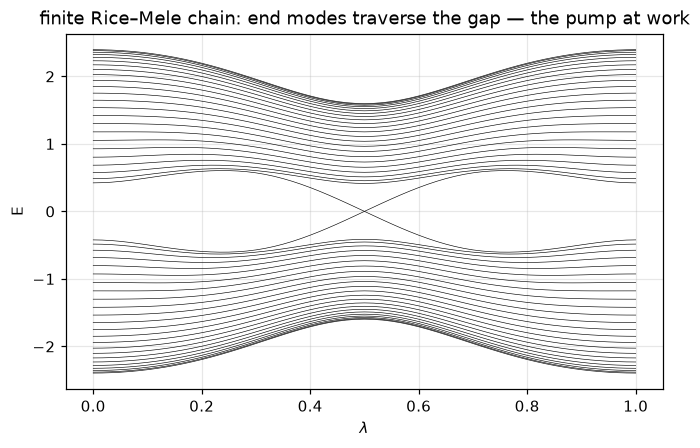

[PASS] spectrum is periodic in λ


True

In [17]:
# the pump seen in a finite chain: end-state energies must cross the gap as λ advances
# (charge has to physically arrive at the boundary)
n_lam = 61
lam_fine = np.linspace(0, 1, n_lam)
spec = []
for lv in lam_fine:
    m_l = rm.with_parameters(lmbda=lv).cut_piece(24, 0)
    spec.append(m_l.solve_ham())
spec = np.array(spec)

fig, ax = plt.subplots()
ax.plot(lam_fine, spec, "k-", lw=0.4)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("E")
ax.set_title("finite Rice–Mele chain: end modes traverse the gap — the pump at work")
plt.show()
caption("The pump seen from a finite chain: as λ advances, bound states peel off "
        "one band edge, cross the gap on the chain's ends, and merge into the other "
        "band. That gap traversal is how the transported charge physically enters "
        "and leaves the sample boundary — the spectral flow that MUST accompany a "
        "nonzero Chern number, here resolved state by state.")

# adiabatic-cycle sanity: spectrum returns to itself after a full period
check("spectrum is periodic in λ", np.allclose(spec[0], spec[-1], atol=1e-10))

In [18]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 2 — checks passed : {_CHECKS['pass']}")
print(f"chapter 2 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 2 — checks passed : 13
chapter 2 — checks failed : 0
wall time                 : 8 s
Every quantitative claim in this notebook was verified in this run.
